# Stage 3: Short-Time Fourier Transform and the Spectrogram

This stage computes the Short-Time Fourier Transform (STFT) of an utterance and visualizes it as a spectrogram, relating the time-frequency structure visible in the image to voicing, pitch, and vocal-tract resonance (formants).

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

DATA_ROOT = "../data/fluent_speech_commands_dataset"
WAV_PATH = f"{DATA_ROOT}/wavs/speakers/2BqVo8kVB2Skwgyb/ac4fca80-447a-11e9-a9a5-5dbec3b8816a.wav"
TRANSCRIPT = "Bring socks"

y, sr = librosa.load(WAV_PATH, sr=None)

## Spectrogram

The STFT is computed using the same 25 ms frame length and 10 ms hop used in Stages 0-2, so that this stage's time axis aligns with the earlier voiced/unvoiced/silence and pitch analyses. The spectrogram is the squared magnitude of the STFT, expressed in decibels relative to the peak value in the utterance.

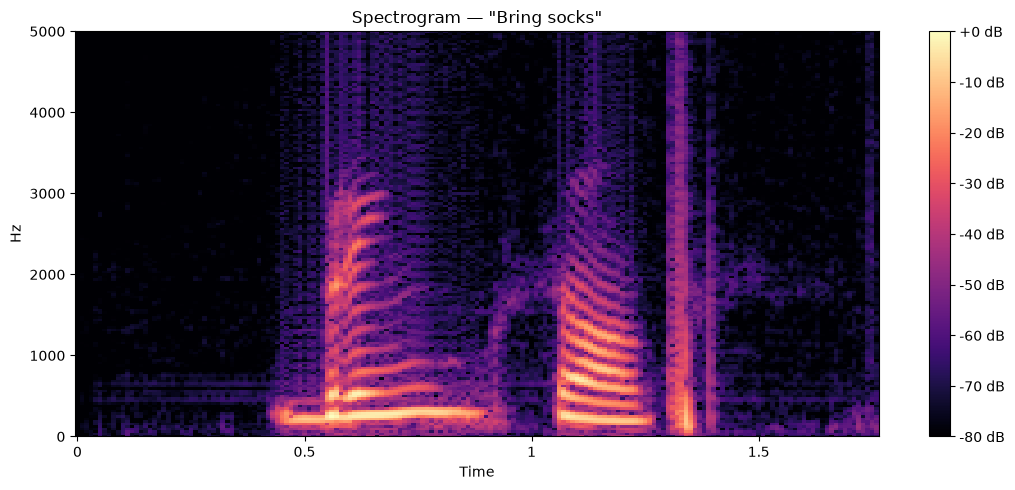

In [2]:
FRAME_MS, HOP_MS = 25, 10
win_length = int(sr * FRAME_MS / 1000)
hop_length = int(sr * HOP_MS / 1000)
n_fft = 512  # smallest power of 2 >= win_length, gives 8000/256 = 31.25 Hz frequency resolution

D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window="hamming")
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

fig, ax = plt.subplots(figsize=(11, 5))
img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="linear",
                                ax=ax, cmap="magma", vmin=-80, vmax=0)
ax.set_ylim(0, 5000)
ax.set_title(f'Spectrogram — "{TRANSCRIPT}"')
fig.colorbar(img, ax=ax, format="%+.0f dB")
fig.tight_layout()
plt.show()

## Narrowband vs. wideband spectrogram

Analysis window length trades frequency resolution against time resolution, the same tradeoff encountered when choosing the frame length in Stage 0. A long window (here 40 ms) resolves individual harmonic lines but blurs rapid time-domain events (narrowband). A short window (here 5 ms) resolves fine time detail, including individual glottal pulses as vertical striations, at the cost of merging adjacent harmonics into broader formant-dominated bands (wideband). Both are computed over the voiced segment corresponding to "Bring" for comparison.

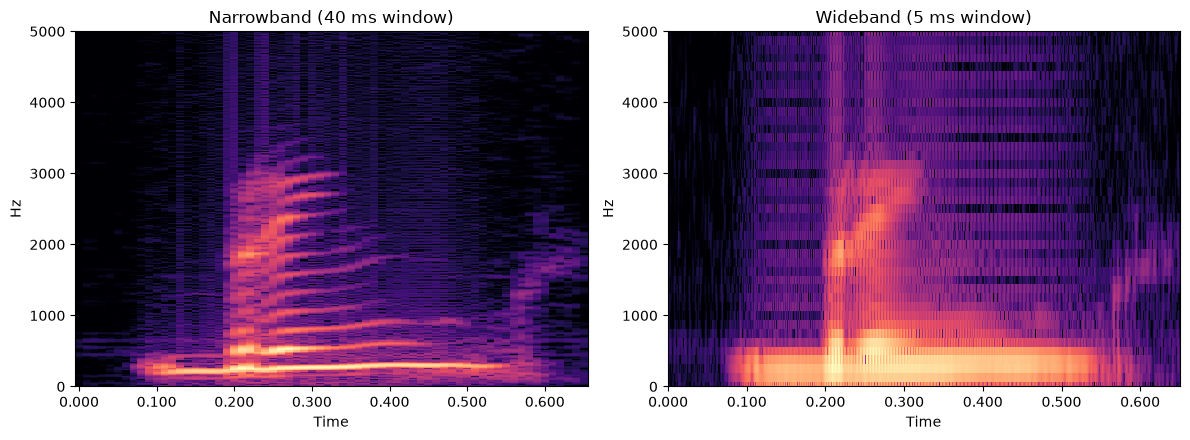

In [3]:
t_start, t_end = 0.35, 1.0
sample_start, sample_end = int(t_start * sr), int(t_end * sr)
y_segment = y[sample_start:sample_end]

configs = [("Narrowband (40 ms window)", 0.040), ("Wideband (5 ms window)", 0.005)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (title, win_s) in zip(axes, configs):
    wl = int(sr * win_s)
    nfft = 2 ** int(np.ceil(np.log2(wl)))
    D_cmp = librosa.stft(y_segment, n_fft=nfft, hop_length=max(wl // 4, 1), win_length=wl, window="hamming")
    S_cmp_db = librosa.amplitude_to_db(np.abs(D_cmp), ref=np.max)
    img = librosa.display.specshow(S_cmp_db, sr=sr, hop_length=max(wl // 4, 1), x_axis="time", y_axis="linear",
                                    ax=ax, cmap="magma", vmin=-80, vmax=0)
    ax.set_ylim(0, 5000)
    ax.set_title(title)
fig.tight_layout()
plt.show()

## Reading the spectrogram

The main spectrogram above should be read alongside the Stage 1 voiced/unvoiced/silence labeling and the Stage 2 pitch contour, both computed on the same time axis for the same utterance. Voiced regions (the vowels in "Bring" and "socks") show horizontal harmonic striations with a broader, non-harmonic band (a formant) gliding independently across the vowel. The stop consonant /k/ appears as a brief, broadband vertical stripe, distinct from the horizontal structure of voicing and the diffuse energy of frication. The /s/ regions in this utterance are comparatively faint across the frequency range, consistent with the low energy already observed for this speaker's fricatives in Stage 1.

In the narrowband/wideband comparison, the 40 ms window resolves individual harmonic lines clearly but blurs the onset of voicing in time; the 5 ms window sharpens the time localization of the onset, visible as faint vertical striations, at the cost of merging adjacent harmonics into broader, formant-dominated bands.

## Results

The harmonic spacing visible in the voiced regions of the spectrogram (approximately 250-300 Hz in "Bring") is consistent with the F0 estimates obtained independently via autocorrelation in Stage 2, providing cross-validation between a time-domain and a frequency-domain pitch estimate. A formant band is visible gliding from approximately 1500 Hz to 3000 Hz across the vowel in "Bring." The stop consonant /k/ (~1.32s) produces a sharp, broadband vertical stripe, visually confirming the Stage 1 observation that this segment does not fit the sustained voiced/unvoiced signature the frame-level classifier expects. The two /s/ segments show no strong energy concentration at any frequency, including near the Nyquist limit (8000 Hz) where sibilant energy is typically expected, consistent with the unusually low short-time energy already measured for this speaker's fricatives in Stage 1 rather than indicating an error in this stage's computation.